# 2. Exploratory Data Analysis (EDA)

This notebook explores the cleaned datasets to understand:
- Sentiment label distribution (class imbalance?)
- Sentence length patterns
- Most frequent words per sentiment class
- Loughran-McDonald dictionary coverage

These insights will directly inform our modeling decisions (class weights, text length truncation, feature engineering).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = '../data/processed'

## 1. Load Processed Datasets

In [2]:
df_strict = pd.read_csv(f'{PROCESSED_DIR}/sentfin_strict.csv')
df_exploded = pd.read_csv(f'{PROCESSED_DIR}/sentfin_exploded.csv')
df_lm = pd.read_csv(f'{PROCESSED_DIR}/LM_Dictionary_Filtered.csv')

print(f'Strict dataset: {df_strict.shape[0]} rows')
print(f'Exploded dataset: {df_exploded.shape[0]} rows')
print(f'LM Dictionary (filtered): {df_lm.shape[0]} words')
print('\n--- Strict Dataset Sample ---')
df_strict.head()

Strict dataset: 9518 rows
Exploded dataset: 14409 rows
LM Dictionary (filtered): 3857 words

--- Strict Dataset Sample ---


,text,sentiment
0,SpiceJet to issue 6.4 crore warrants to promoters,neutral
1,MMTC Q2 net loss at Rs 10.4 crore,neutral
2,"Mid-cap funds can deliver more, stay put: Experts",positive
3,Mid caps now turn into market darlings,positive
4,"Market seeing patience, if not conviction: Pra...",neutral


## 2. Sentiment Label Distribution
Check for class imbalance — a common issue in financial sentiment data.

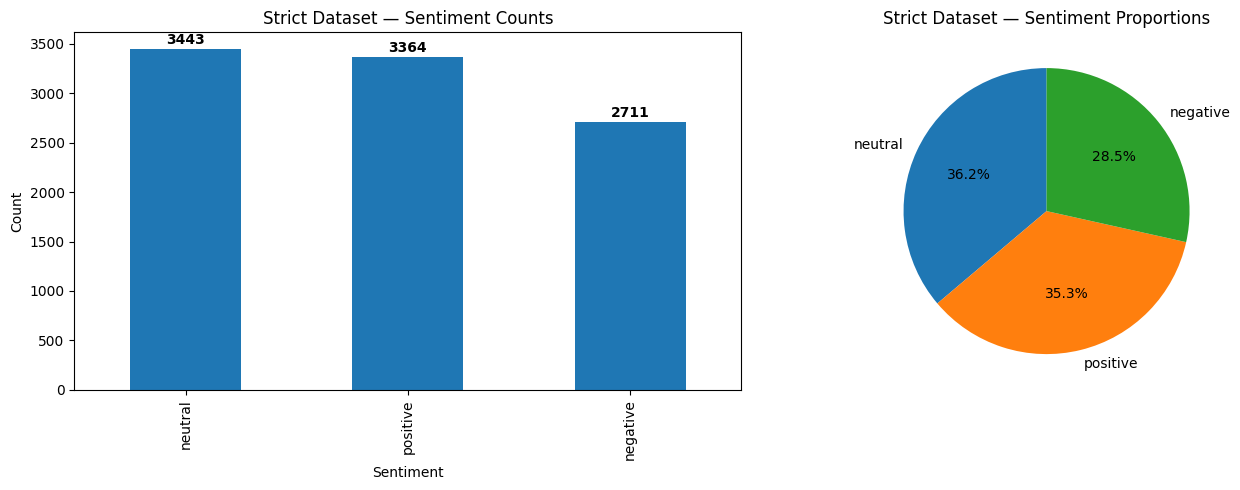


Class distribution (strict):
sentiment
neutral     3443
positive    3364
negative    2711
Name: count, dtype: int64

Imbalance ratio (max/min): 1.27x


In [4]:
# --- Strict Dataset ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Bar chart
counts_strict = df_strict['sentiment'].value_counts()
counts_strict.plot(kind='bar', ax=axes[0])
axes[0].set_title('Strict Dataset — Sentiment Counts')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Sentiment')
for i, v in enumerate(counts_strict.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
counts_strict.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Strict Dataset — Sentiment Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\nClass distribution (strict):')
print(counts_strict)
print(f'\nImbalance ratio (max/min): {counts_strict.max() / counts_strict.min():.2f}x')

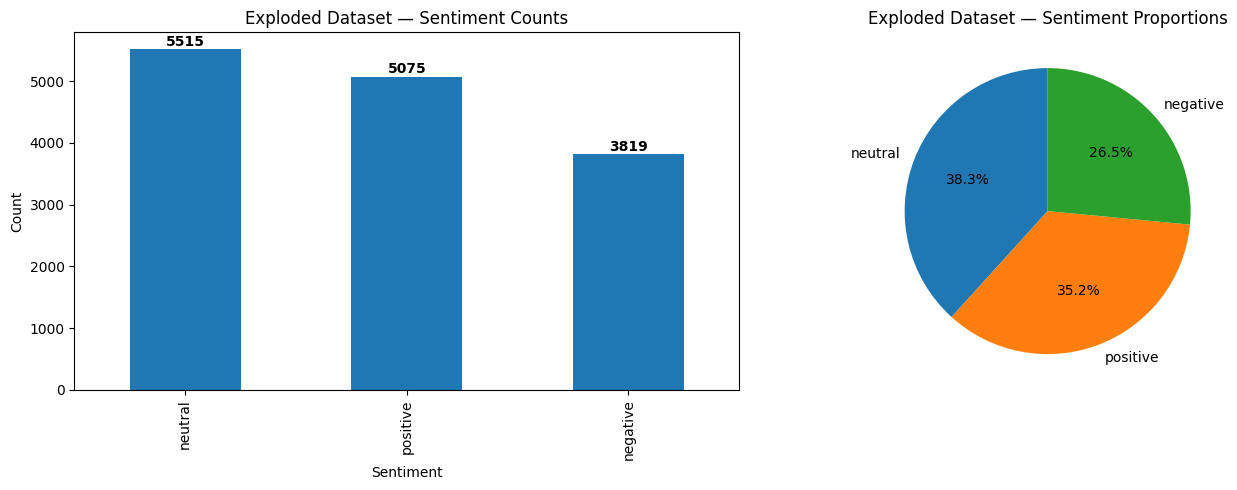


Class distribution (exploded):
sentiment
neutral     5515
positive    5075
negative    3819
Name: count, dtype: int64

Imbalance ratio (max/min): 1.44x


In [6]:
# --- Exploded Dataset ---
counts_exploded = df_exploded['sentiment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts_exploded.plot(kind='bar', ax=axes[0])
axes[0].set_title('Exploded Dataset — Sentiment Counts')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Sentiment')
for i, v in enumerate(counts_exploded.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

counts_exploded.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Exploded Dataset — Sentiment Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('\nClass distribution (exploded):')
print(counts_exploded)
print(f'\nImbalance ratio (max/min): {counts_exploded.max() / counts_exploded.min():.2f}x')

## 3. Sentence Length Analysis
Understanding text length helps decide on padding/truncation for neural models later.

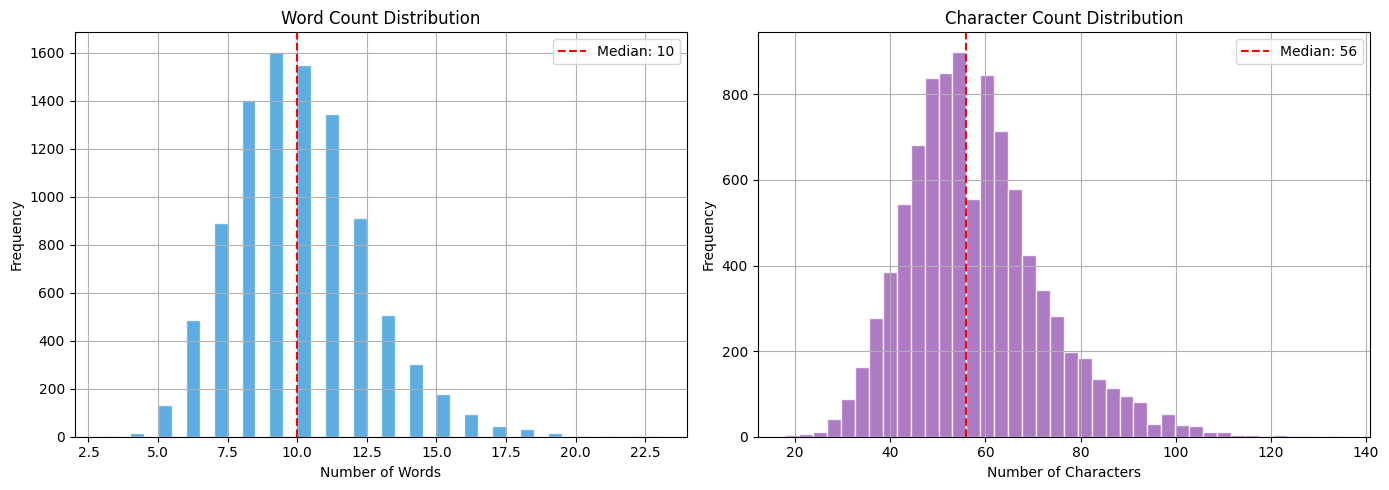

       word_count  char_count
count      9518.0      9518.0
mean          9.8        58.0
std           2.4        14.4
min           3.0        18.0
25%           8.0        48.0
50%          10.0        56.0
75%          11.0        66.0
max          23.0       135.0


In [7]:
df_strict['word_count'] = df_strict['text'].str.split().str.len()
df_strict['char_count'] = df_strict['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
df_strict['word_count'].hist(bins=40, ax=axes[0], color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_strict['word_count'].median(), color='red', linestyle='--', label=f'Median: {df_strict["word_count"].median():.0f}')
axes[0].legend()

# Character count distribution
df_strict['char_count'].hist(bins=40, ax=axes[1], color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_title('Character Count Distribution')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_strict['char_count'].median(), color='red', linestyle='--', label=f'Median: {df_strict["char_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df_strict[['word_count', 'char_count']].describe().round(1))

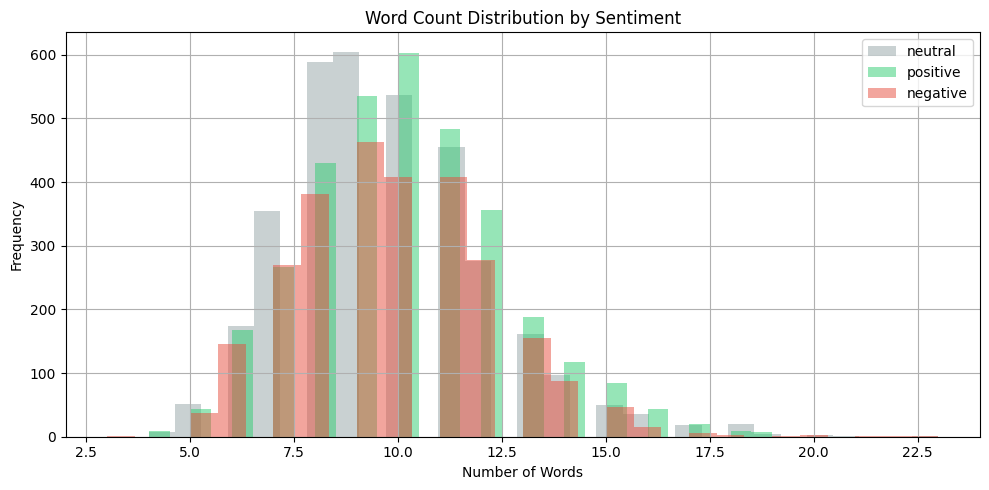

In [8]:
# Word count distribution by sentiment class
fig, ax = plt.subplots(figsize=(10, 5))

for sentiment in df_strict['sentiment'].unique():
    subset = df_strict[df_strict['sentiment'] == sentiment]
    subset['word_count'].hist(bins=30, alpha=0.5, label=sentiment,
                              color=colors.get(sentiment, '#3498db'), ax=ax)

ax.set_title('Word Count Distribution by Sentiment')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Most Common Words by Sentiment
Quick look at what words dominate in each sentiment class.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91915\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


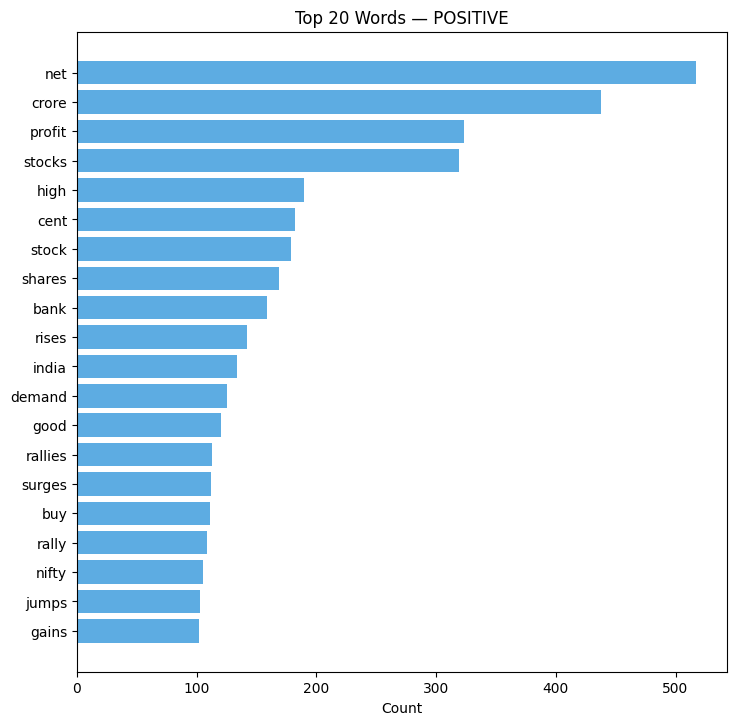

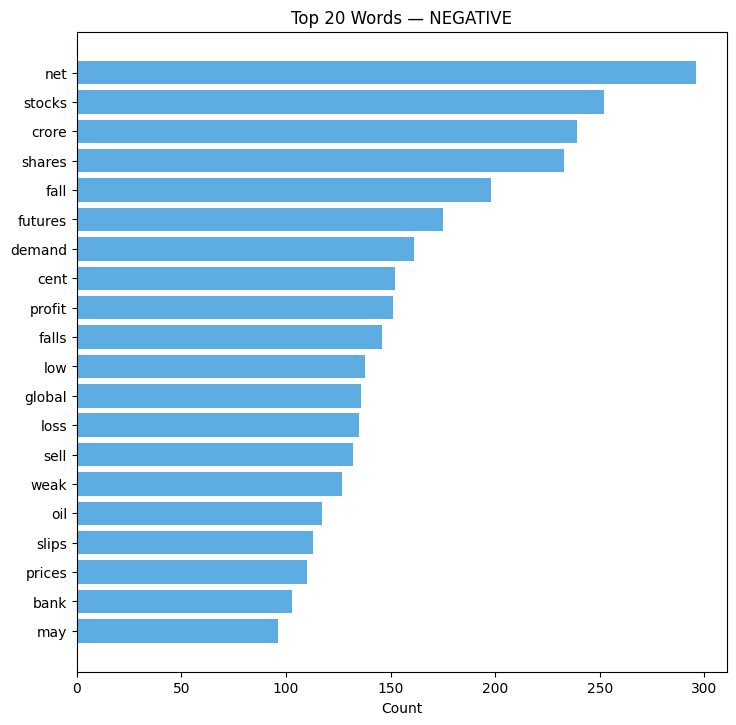

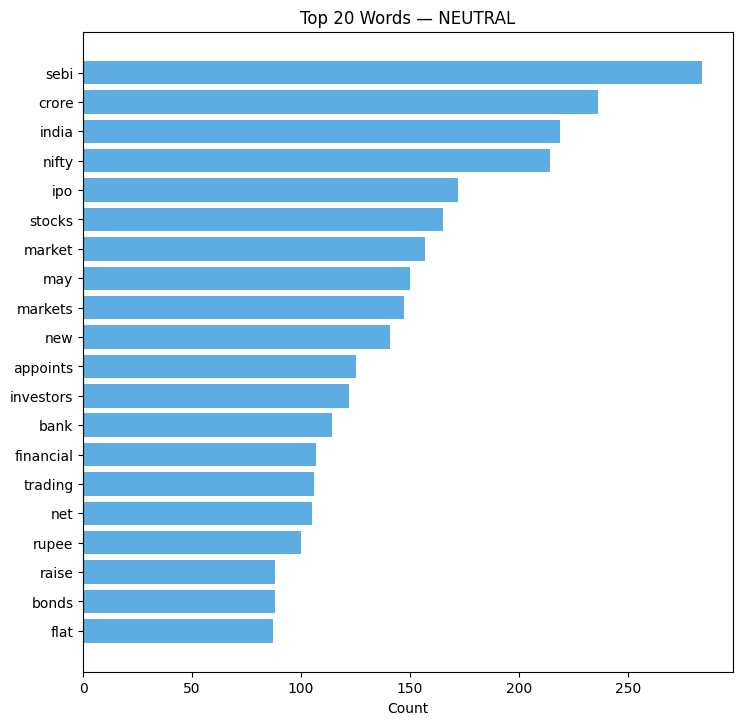

In [11]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
official_stopwords = set(stopwords.words('english'))
additional_stops = {'vs', 'per', 'said'}
stop_words = official_stopwords.union(additional_stops)

def get_top_words(texts, n=20):
    all_words = []
    punc_table = str.maketrans('', '', string.punctuation)
    for text in texts:
        words = str(text).lower().translate(punc_table).split()
        all_words.extend([w for w in words if w not in stop_words and len(w) > 2])
    return Counter(all_words).most_common(n)

for sentiment in ['positive', 'negative', 'neutral']:
    subset = df_strict[df_strict['sentiment'] == sentiment]
    top_words = get_top_words(subset['text'])
    
    if top_words:
        plt.figure(figsize=(10, 8))
        words, counts = zip(*top_words)
        
        plt.barh(range(len(words)), counts, color='#3498db', alpha=0.8)
        plt.yticks(range(len(words)), words)
        plt.gca().invert_yaxis()
        plt.title(f'Top 20 Words — {sentiment.upper()}')
        plt.xlabel('Count')
        
        plt.subplots_adjust(left=0.25, right=0.9, top=0.9, bottom=0.1)
        plt.show()

## 5. Loughran-McDonald Dictionary Overview
Understand the composition of the filtered finance-specific sentiment lexicon.

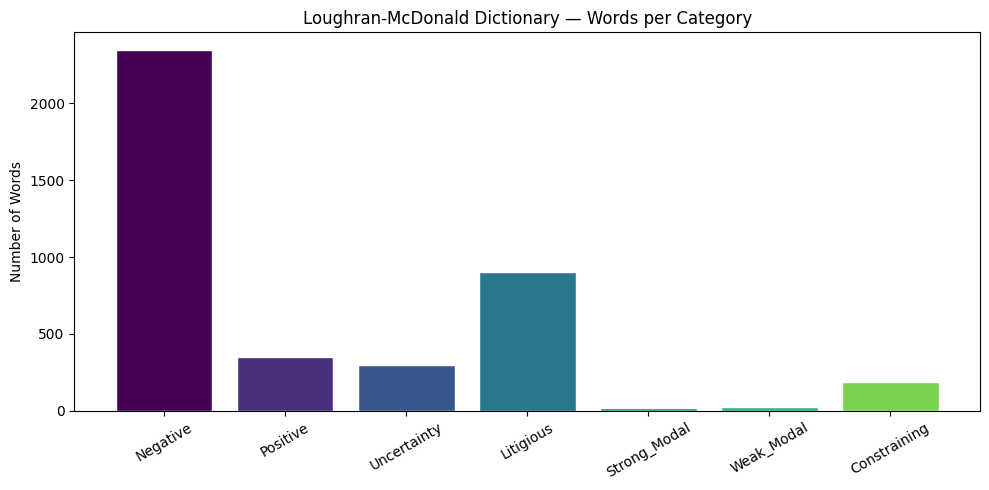


Total unique words in filtered dictionary: 3857

Sample negative words: ['abandon', 'abandoned', 'abandoning', 'abandonment', 'abandonments', 'abandons', 'abdicated', 'abdicates', 'abdicating', 'abdication']
Sample positive words: ['able', 'abundance', 'abundant', 'acclaimed', 'accomplish', 'accomplished', 'accomplishes', 'accomplishing', 'accomplishment', 'accomplishments']


In [15]:
# Define sentiment categories
sentiment_cols = ['Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal', 'Constraining']

# Count occurrences per category
category_counts = {}
for col in sentiment_cols:
    category_counts[col] = (df_lm[col] > 0).sum()

fig, ax = plt.subplots(figsize=(10, 5))

# Generate shades from the viridis colormap
colors = plt.cm.viridis(np.linspace(0, 0.8, len(sentiment_cols)))

# Create the bar chart
bars = ax.bar(category_counts.keys(), category_counts.values(), color=colors, edgecolor='white')

# Set chart labels and title
ax.set_title('Loughran-McDonald Dictionary — Words per Category')
ax.set_ylabel('Number of Words')

# Formatting for readability
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Display summary statistics
print(f'\nTotal unique words in filtered dictionary: {len(df_lm)}')
print(f'\nSample negative words: {df_lm[df_lm["Negative"] > 0]["Word"].head(10).tolist()}')
print(f'Sample positive words: {df_lm[df_lm["Positive"] > 0]["Word"].head(10).tolist()}')

## 6. LM Dictionary Coverage on Our Dataset
How many words in our headlines actually appear in the Loughran-McDonald lexicon?

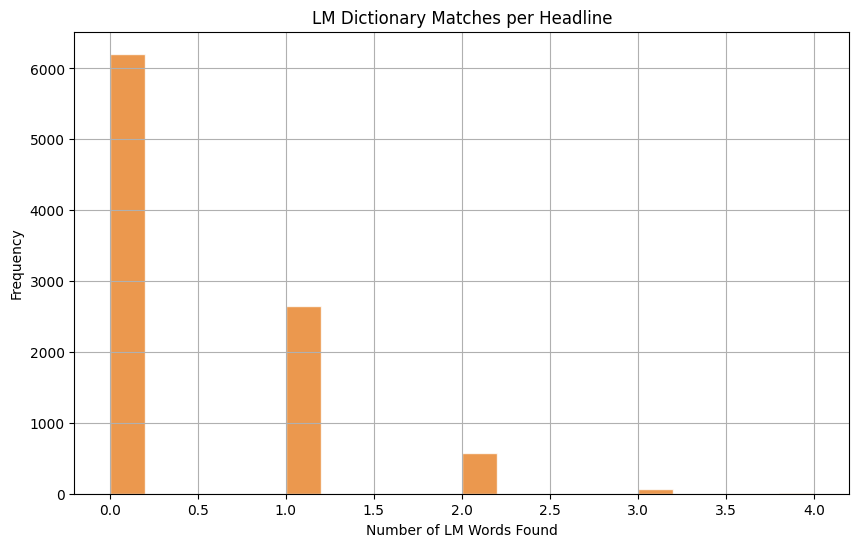

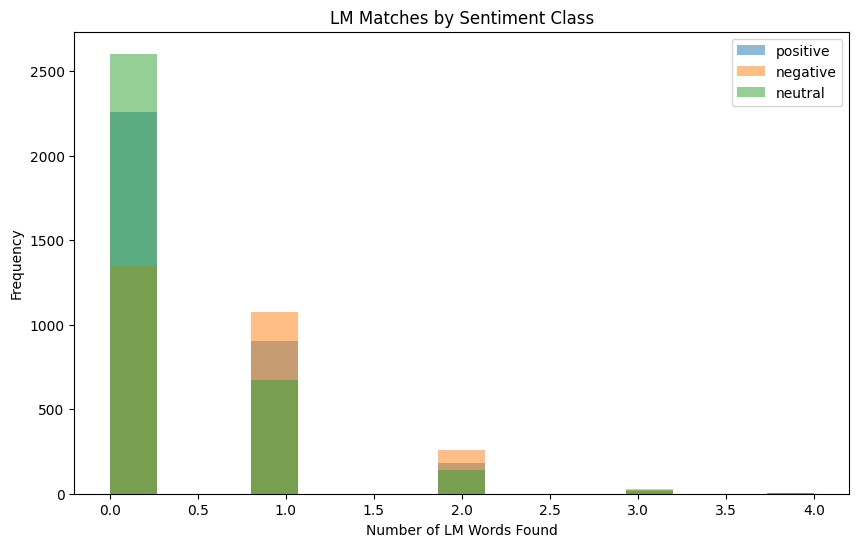


34.8% of headlines contain at least one LM dictionary word.
Average LM words per headline: 0.43

Average LM matches by sentiment:
sentiment
negative    0.62
neutral     0.30
positive    0.40
Name: lm_match_count, dtype: float64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import string

lm_words = set(df_lm['Word'].str.lower().tolist())

def count_lm_matches(text):
    punc_table = str.maketrans('', '', string.punctuation)
    words = str(text).lower().translate(punc_table).split()
    matches = [w for w in words if w in lm_words]
    return len(matches)

df_strict['lm_match_count'] = df_strict['text'].apply(count_lm_matches)

plt.figure(figsize=(10, 6))
df_strict['lm_match_count'].hist(bins=20, color='#e67e22', edgecolor='white', alpha=0.8)
plt.title('LM Dictionary Matches per Headline')
plt.xlabel('Number of LM Words Found')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
for sentiment in ['positive', 'negative', 'neutral']:
    subset = df_strict[df_strict['sentiment'] == sentiment]
    plt.hist(subset['lm_match_count'], bins=15, alpha=0.5,
                label=sentiment)

plt.title('LM Matches by Sentiment Class')
plt.xlabel('Number of LM Words Found')
plt.ylabel('Frequency')
plt.legend()
plt.show()

coverage = (df_strict['lm_match_count'] > 0).mean() * 100
print(f'\n{coverage:.1f}% of headlines contain at least one LM dictionary word.')
print(f'Average LM words per headline: {df_strict["lm_match_count"].mean():.2f}')
print(f'\nAverage LM matches by sentiment:')
print(df_strict.groupby('sentiment')['lm_match_count'].mean().round(2))

## 7. Missing Values & Data Quality Check

In [18]:
print('=== Strict Dataset ===')
print(f'Total rows: {len(df_strict)}')
print(f'Missing values:\n{df_strict[["text", "sentiment"]].isnull().sum()}')
print(f'\nDuplicate texts: {df_strict["text"].duplicated().sum()}')
print(f'Unique sentiments: {df_strict["sentiment"].unique().tolist()}')

print('\n=== Exploded Dataset ===')
print(f'Total rows: {len(df_exploded)}')
print(f'Missing values:\n{df_exploded.isnull().sum()}')
print(f'\nDuplicate (text, entity) pairs: {df_exploded.duplicated(subset=["text", "entity"]).sum()}')
print(f'Unique sentiments: {df_exploded["sentiment"].unique().tolist()}')

=== Strict Dataset ===
Total rows: 9518
Missing values:
text         0
sentiment    0
dtype: int64

Duplicate texts: 59
Unique sentiments: ['neutral', 'positive', 'negative']

=== Exploded Dataset ===
Total rows: 14409
Missing values:
text         0
entity       0
sentiment    0
dtype: int64

Duplicate (text, entity) pairs: 80
Unique sentiments: ['neutral', 'positive', 'negative']
